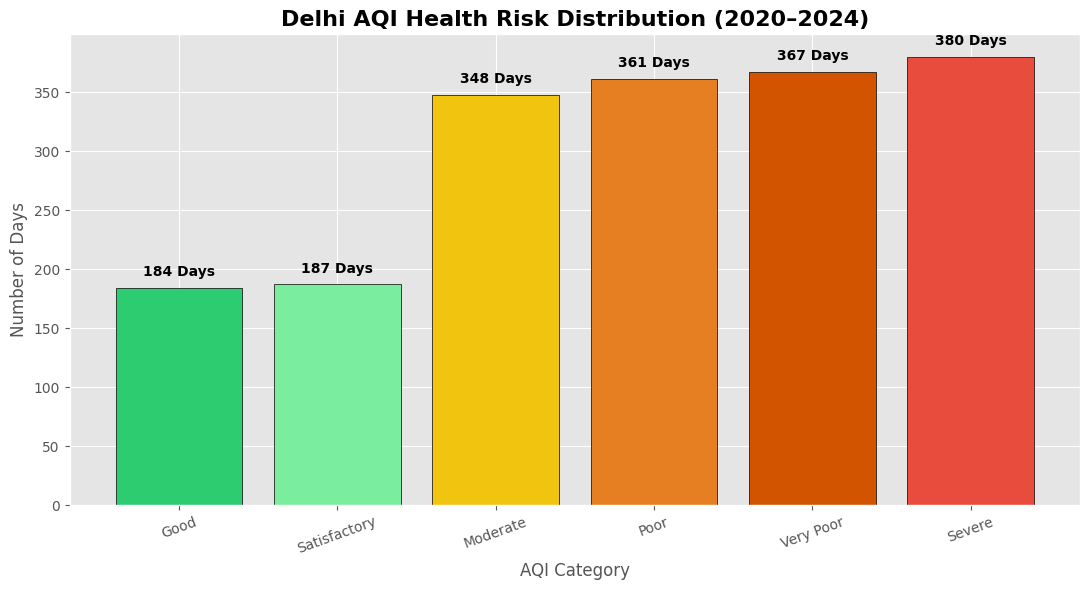

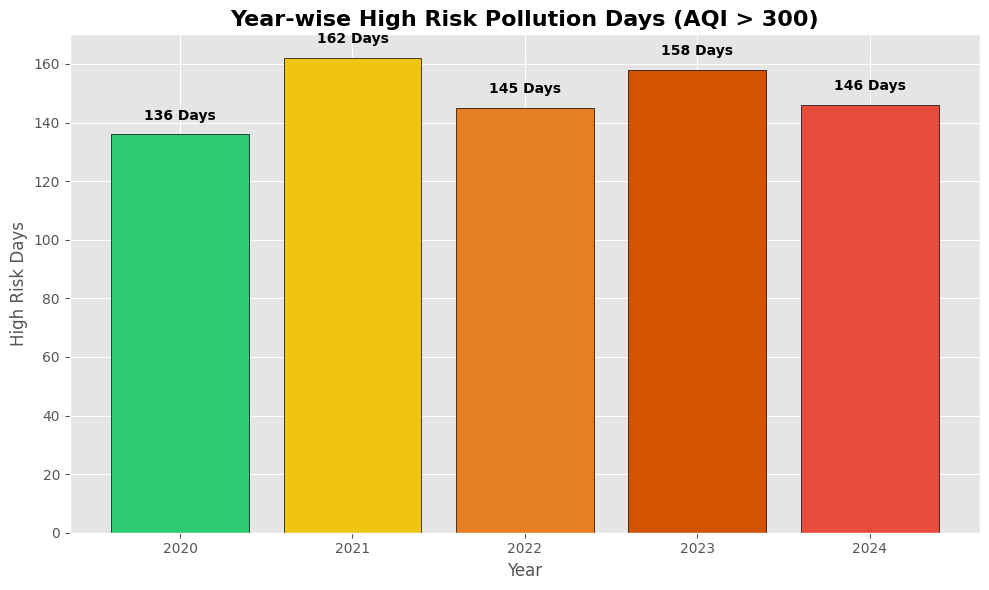


DELHI AQI HEALTH IMPACT GUIDE
AQI Category                     Health Impact
        Good                  Safe air quality
Satisfactory              Generally acceptable
    Moderate Sensitive groups should take care
        Poor     Breathing discomfort possible
   Very Poor    Serious respiratory discomfort
      Severe             Emergency health risk

HEALTH INTELLIGENCE EXECUTIVE INSIGHTS
Total Records Analysed (2020–2024): 1827
High Risk Pollution Days (AQI > 300): 747
Severe Emergency Pollution Days (AQI > 400): 380

Interpretation:
- High AQI exposure indicates serious long-term respiratory risk.
- AQI above 300 is considered hazardous for sensitive groups.
- Severe AQI days represent public health emergency conditions.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# ==========================================
# LOAD DATA
# ==========================================

csv_path = r"C:\Users\hi\Desktop\AQI MAJOR PROJECT\data\cleaned_aqi_final.csv"

df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# ==========================================
# AQI CATEGORY CLASSIFICATION
# ==========================================

def classify_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

df['AQI_Category'] = df['AQI'].apply(classify_aqi)

# ==========================================
# 1. AQI HEALTH RISK DISTRIBUTION
# ==========================================

category_counts = df['AQI_Category'].value_counts().reindex([
    'Good',
    'Satisfactory',
    'Moderate',
    'Poor',
    'Very Poor',
    'Severe'
])

plt.figure(figsize=(11, 6))

colors = [
    '#2ecc71',
    '#7bed9f',
    '#f1c40f',
    '#e67e22',
    '#d35400',
    '#e74c3c'
]

bars = plt.bar(
    category_counts.index,
    category_counts.values,
    color=colors,
    edgecolor='black'
)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 10,
        f"{int(y)} Days",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Delhi AQI Health Risk Distribution (2020–2024)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("AQI Category")
plt.ylabel("Number of Days")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ==========================================
# 2. YEAR-WISE HIGH RISK DAYS
# ==========================================

# Better health burden metric
# AQI > 300 means Very Poor + Severe

high_risk = df[df['AQI'] > 300].groupby('Year').size()

plt.figure(figsize=(10, 6))

bars = plt.bar(
    high_risk.index.astype(str),
    high_risk.values,
    color=['#2ecc71', '#f1c40f', '#e67e22', '#d35400', '#e74c3c'],
    edgecolor='black'
)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 5,
        f"{int(y)} Days",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Year-wise High Risk Pollution Days (AQI > 300)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year")
plt.ylabel("High Risk Days")
plt.tight_layout()
plt.show()

# ==========================================
# 3. HEALTH IMPACT GUIDE
# ==========================================

health_guide = pd.DataFrame({
    'AQI Category': [
        'Good',
        'Satisfactory',
        'Moderate',
        'Poor',
        'Very Poor',
        'Severe'
    ],
    'Health Impact': [
        'Safe air quality',
        'Generally acceptable',
        'Sensitive groups should take care',
        'Breathing discomfort possible',
        'Serious respiratory discomfort',
        'Emergency health risk'
    ]
})

print("\n" + "="*70)
print("DELHI AQI HEALTH IMPACT GUIDE")
print("="*70)
print(health_guide.to_string(index=False))

# ==========================================
# 4. EXECUTIVE INSIGHTS
# ==========================================

total_days = len(df)
high_risk_days = len(df[df['AQI'] > 300])
severe_days = len(df[df['AQI'] > 400])

print("\n" + "="*70)
print("HEALTH INTELLIGENCE EXECUTIVE INSIGHTS")
print("="*70)

print(f"Total Records Analysed (2020–2024): {total_days}")
print(f"High Risk Pollution Days (AQI > 300): {high_risk_days}")
print(f"Severe Emergency Pollution Days (AQI > 400): {severe_days}")

print("\nInterpretation:")
print("- High AQI exposure indicates serious long-term respiratory risk.")
print("- AQI above 300 is considered hazardous for sensitive groups.")
print("- Severe AQI days represent public health emergency conditions.")

print("="*70)